# Question 2.1: The Robustness Duel
## Comparing FCNN vs CNN on Shifted MNIST

**Goal**: Compare how well a Fully Connected Neural Network (FCNN) and a Convolutional Neural Network (CNN) handle spatial translations in images.

**Test**: Shift MNIST images 4 pixels to the right and measure accuracy drop.

### 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
 
torch.manual_seed(42)
np.random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### 2. Load MNIST Dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  
])
 
train_dataset = datasets.MNIST(root='./MNIST', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./MNIST', train=False, download=True, transform=transform)
 
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:04<00:00, 2.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 103kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 675kB/s] 
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Training samples: 60000
Test samples: 10000


### 3. Visualize Original MNIST Images

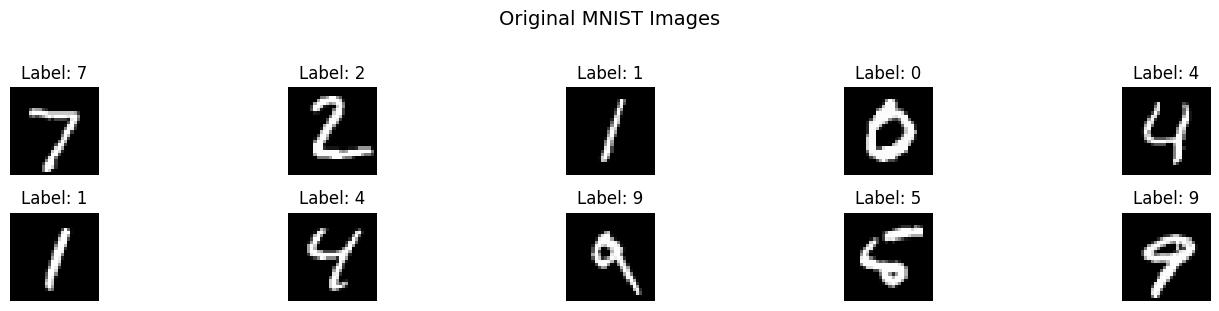

In [3]:
sample_images, sample_labels = next(iter(test_loader))
 
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = sample_images[i].squeeze().numpy()
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {sample_labels[i].item()}")
    plt.axis('off')
plt.suptitle('Original MNIST Images', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4. Create Shifted MNIST Test Set

We'll shift each image 4 pixels to the right.

In [4]:
def shift_images_right(images, shift_pixels=4):  
    shifted = torch.zeros_like(images)
     
    shifted[:, :, :, shift_pixels:] = images[:, :, :, :-shift_pixels]
    
    return shifted
 
test_shift = shift_images_right(sample_images[:10], shift_pixels=4)
print(f"Original shape: {sample_images.shape}")
print(f"Shifted shape: {test_shift.shape}")

Original shape: torch.Size([128, 1, 28, 28])
Shifted shape: torch.Size([10, 1, 28, 28])


### 5. Visualize Original vs Shifted Images

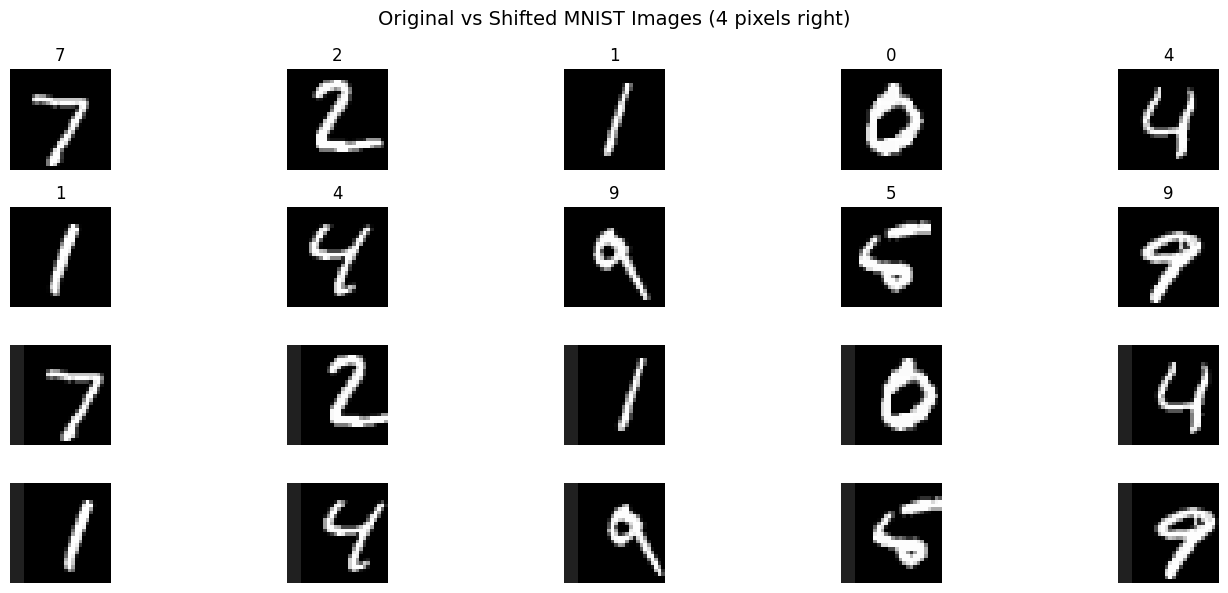

In [5]:
plt.figure(figsize=(15, 6))

for i in range(10): 
    plt.subplot(4, 5, i+1)
    plt.imshow(sample_images[i].squeeze().numpy(), cmap='gray')
    if i == 0:
        plt.ylabel('Original', fontsize=12, fontweight='bold')
    plt.title(f"{sample_labels[i].item()}")
    plt.axis('off')
     
    plt.subplot(4, 5, i+11)
    plt.imshow(test_shift[i].squeeze().numpy(), cmap='gray')
    if i == 0:
        plt.ylabel('Shifted 4px →', fontsize=12, fontweight='bold')
    plt.axis('off')

plt.suptitle('Original vs Shifted MNIST Images (4 pixels right)', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

### 6. Create Complete Shifted Test Dataset

In [6]:
all_test_images = []
all_test_labels = []
 
for images, labels in test_loader:
    all_test_images.append(images)
    all_test_labels.append(labels)
 
all_test_images = torch.cat(all_test_images, dim=0)
all_test_labels = torch.cat(all_test_labels, dim=0)
 
shifted_test_images = shift_images_right(all_test_images, shift_pixels=4)
 
shifted_test_dataset = TensorDataset(shifted_test_images, all_test_labels)
shifted_test_loader = DataLoader(shifted_test_dataset, batch_size=batch_size, shuffle=False)

print(f"Shifted test images shape: {shifted_test_images.shape}")
print(f"Shifted test labels shape: {all_test_labels.shape}")

Shifted test images shape: torch.Size([10000, 1, 28, 28])
Shifted test labels shape: torch.Size([10000])


### 7. Define Model Architectures

#### Model A: FCNN (from previous assignment)

In [7]:
class FCNN(nn.Module): 
    def __init__(self):
        super(FCNN, self).__init__() 
        self.input = nn.Linear(28*28, 128)   
        self.h1 = nn.Linear(128, 128)
        self.h2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 10)
        
    def forward(self, x): 
        x = x.view(x.size(0), -1)  
         
        x = torch.relu(self.input(x))
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = self.out(x)
        return x

# Create FCNN model
fcnn_model = FCNN().to(device)
print("\nModel A: FCNN")
print("="*50)
print(fcnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in fcnn_model.parameters()):,}")


Model A: FCNN
FCNN(
  (input): Linear(in_features=784, out_features=128, bias=True)
  (h1): Linear(in_features=128, out_features=128, bias=True)
  (h2): Linear(in_features=128, out_features=128, bias=True)
  (out): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 134,794


#### Model B: Simple 2-Layer CNN

In [8]:
class SimpleCNN(nn.Module): 
    def __init__(self):
        super(SimpleCNN, self).__init__()
         
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
         
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
         
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
         
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x): 
        x = self.pool(torch.relu(self.conv1(x)))  
         
        x = self.pool(torch.relu(self.conv2(x)))   
         
        x = x.view(x.size(0), -1)   
         
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
 
cnn_model = SimpleCNN().to(device)
print("\nModel B: CNN")
print("="*50)
print(cnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")


Model B: CNN
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 421,642


### 8. Training and Evaluation Functions

In [ ]:
def train_model(model, train_loader, epochs=10, lr=0.001): 
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    model.train()
    train_losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
         
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
             
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
             
            loss.backward()
            optimizer.step()
             
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
             
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 
                            'acc': f'{100*correct/total:.2f}%'})
        
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        accuracy = 100 * correct / total
        
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {accuracy:.2f}%")
    
    return train_losses


def evaluate_model(model, test_loader, dataset_name="Test"): 
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f"{dataset_name} Accuracy: {accuracy:.2f}%")
    
    return accuracy

### 9. Train Model A (FCNN)

In [10]:
print("\n" + "="*60)
print("TRAINING MODEL A: FCNN")
print("="*60 + "\n")

fcnn_losses = train_model(fcnn_model, train_loader, epochs=10, lr=0.001)


TRAINING MODEL A: FCNN



Epoch 1/10: 100%|██████████| 469/469 [00:16<00:00, 28.90it/s, loss=0.1705, acc=90.42%]


Epoch 1: Loss = 0.3258, Accuracy = 90.42%


Epoch 2/10: 100%|██████████| 469/469 [00:12<00:00, 38.55it/s, loss=0.0921, acc=96.20%]


Epoch 2: Loss = 0.1240, Accuracy = 96.20%


...

Epoch 8: Loss = 0.0325, Accuracy = 98.93%


Epoch 9/10: 100%|██████████| 469/469 [00:13<00:00, 35.60it/s, loss=0.0844, acc=99.06%]


Epoch 9: Loss = 0.0284, Accuracy = 99.06%


Epoch 10/10: 100%|██████████| 469/469 [00:12<00:00, 39.00it/s, loss=0.0449, acc=99.17%]

Epoch 10: Loss = 0.0256, Accuracy = 99.17%


### 10. Train Model B (CNN)

In [11]:
print("\n" + "="*60)
print("TRAINING MODEL B: CNN")
print("="*60 + "\n")

cnn_losses = train_model(cnn_model, train_loader, epochs=10, lr=0.001)


TRAINING MODEL B: CNN



Epoch 1/10: 100%|██████████| 469/469 [00:41<00:00, 11.43it/s, loss=0.0801, acc=94.82%]


Epoch 1: Loss = 0.1759, Accuracy = 94.82%


Epoch 2/10: 100%|██████████| 469/469 [00:41<00:00, 11.29it/s, loss=0.0784, acc=98.46%]


Epoch 2: Loss = 0.0497, Accuracy = 98.46%


...

Epoch 8: Loss = 0.0104, Accuracy = 99.64%


Epoch 9/10: 100%|██████████| 469/469 [00:48<00:00,  9.57it/s, loss=0.0043, acc=99.69%]


Epoch 9: Loss = 0.0086, Accuracy = 99.69%


Epoch 10/10: 100%|██████████| 469/469 [00:53<00:00,  8.81it/s, loss=0.0017, acc=99.73%]

Epoch 10: Loss = 0.0078, Accuracy = 99.73%


### 11. Compare Training Progress

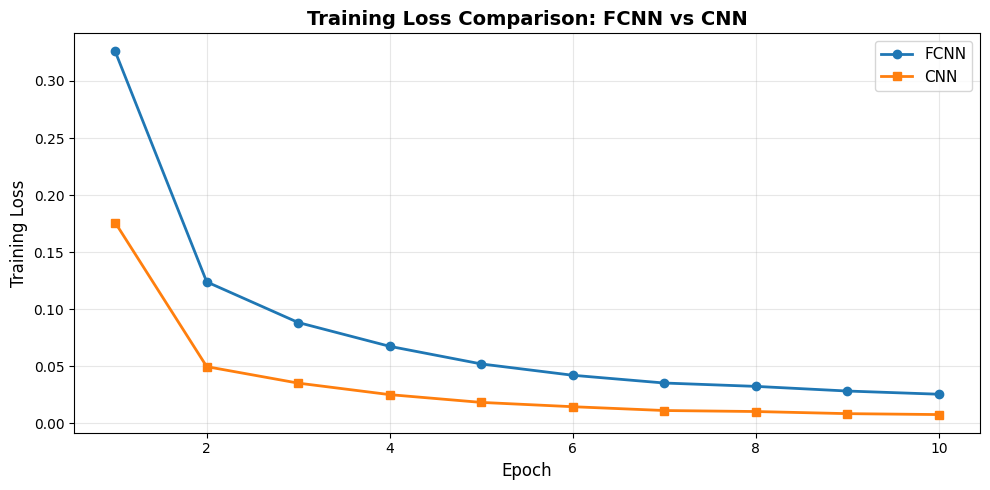

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(fcnn_losses)+1), fcnn_losses, 'o-', label='FCNN', linewidth=2, markersize=6)
plt.plot(range(1, len(cnn_losses)+1), cnn_losses, 's-', label='CNN', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss Comparison: FCNN vs CNN', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 12. Evaluate on Original Test Set

In [13]:
print("\n" + "="*60)
print("EVALUATION ON ORIGINAL TEST SET")
print("="*60 + "\n")

print("Model A (FCNN):")
fcnn_original_acc = evaluate_model(fcnn_model, test_loader, "Original Test")

print("\nModel B (CNN):")
cnn_original_acc = evaluate_model(cnn_model, test_loader, "Original Test")


EVALUATION ON ORIGINAL TEST SET

Model A (FCNN):
Original Test Accuracy: 97.29%

Model B (CNN):
Original Test Accuracy: 99.05%


### 13. Evaluate on Shifted Test Set (THE KEY TEST!)

In [14]:
print("\n" + "="*60)
print("EVALUATION ON SHIFTED TEST SET (4 PIXELS RIGHT)")
print("="*60 + "\n")

print("Model A (FCNN):")
fcnn_shifted_acc = evaluate_model(fcnn_model, shifted_test_loader, "Shifted Test")

print("\nModel B (CNN):")
cnn_shifted_acc = evaluate_model(cnn_model, shifted_test_loader, "Shifted Test")


EVALUATION ON SHIFTED TEST SET (4 PIXELS RIGHT)

Model A (FCNN):
Shifted Test Accuracy: 35.25%

Model B (CNN):
Shifted Test Accuracy: 72.59%


### 14. Calculate Accuracy Drops

In [15]:
fcnn_drop = fcnn_original_acc - fcnn_shifted_acc
cnn_drop = cnn_original_acc - cnn_shifted_acc

print("\n" + "="*60)
print("ACCURACY DROP SUMMARY")
print("="*60 + "\n")

print(f"Model A (FCNN):")
print(f"  Original Test Accuracy:  {fcnn_original_acc:.2f}%")
print(f"  Shifted Test Accuracy:   {fcnn_shifted_acc:.2f}%")
print(f"  Accuracy Drop:           {fcnn_drop:.2f}%")
print(f"  Relative Drop:           {(fcnn_drop/fcnn_original_acc)*100:.2f}%\n")

print(f"Model B (CNN):")
print(f"  Original Test Accuracy:  {cnn_original_acc:.2f}%")
print(f"  Shifted Test Accuracy:   {cnn_shifted_acc:.2f}%")
print(f"  Accuracy Drop:           {cnn_drop:.2f}%")
print(f"  Relative Drop:           {(cnn_drop/cnn_original_acc)*100:.2f}%\n")

print("="*60)
print(f"CNN is {fcnn_drop/cnn_drop:.2f}x more robust than FCNN!")
print("="*60)


ACCURACY DROP SUMMARY

Model A (FCNN):
  Original Test Accuracy:  97.29%
  Shifted Test Accuracy:   35.25%
  Accuracy Drop:           62.04%
  Relative Drop:           63.77%

Model B (CNN):
  Original Test Accuracy:  99.05%
  Shifted Test Accuracy:   72.59%
  Accuracy Drop:           26.46%
  Relative Drop:           26.71%

CNN is 2.34x more robust than FCNN!


### 15. Visualize Results

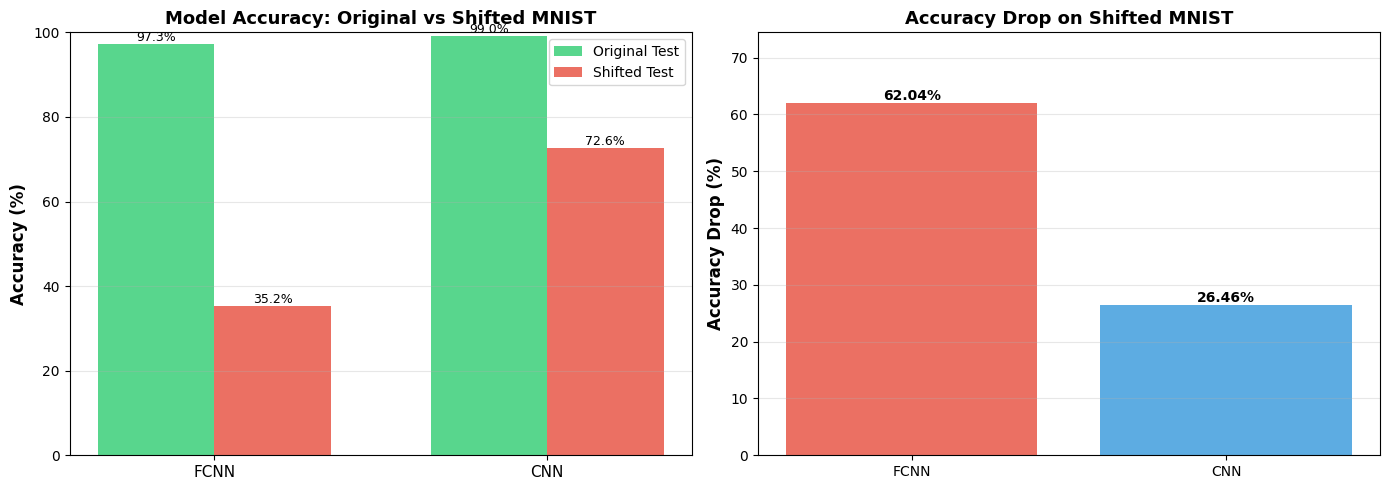

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
models = ['FCNN', 'CNN']
original_accs = [fcnn_original_acc, cnn_original_acc]
shifted_accs = [fcnn_shifted_acc, cnn_shifted_acc]

x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, original_accs, width, label='Original Test', color='#2ecc71', alpha=0.8)
bars2 = axes[0].bar(x + width/2, shifted_accs, width, label='Shifted Test', color='#e74c3c', alpha=0.8)

axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy: Original vs Shifted MNIST', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 100])
 
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
 
drops = [fcnn_drop, cnn_drop]
colors = ['#e74c3c', '#3498db']
bars = axes[1].bar(models, drops, color=colors, alpha=0.8)

axes[1].set_ylabel('Accuracy Drop (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Accuracy Drop on Shifted MNIST', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, max(drops) * 1.2])

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 16. Visualize Sample Predictions

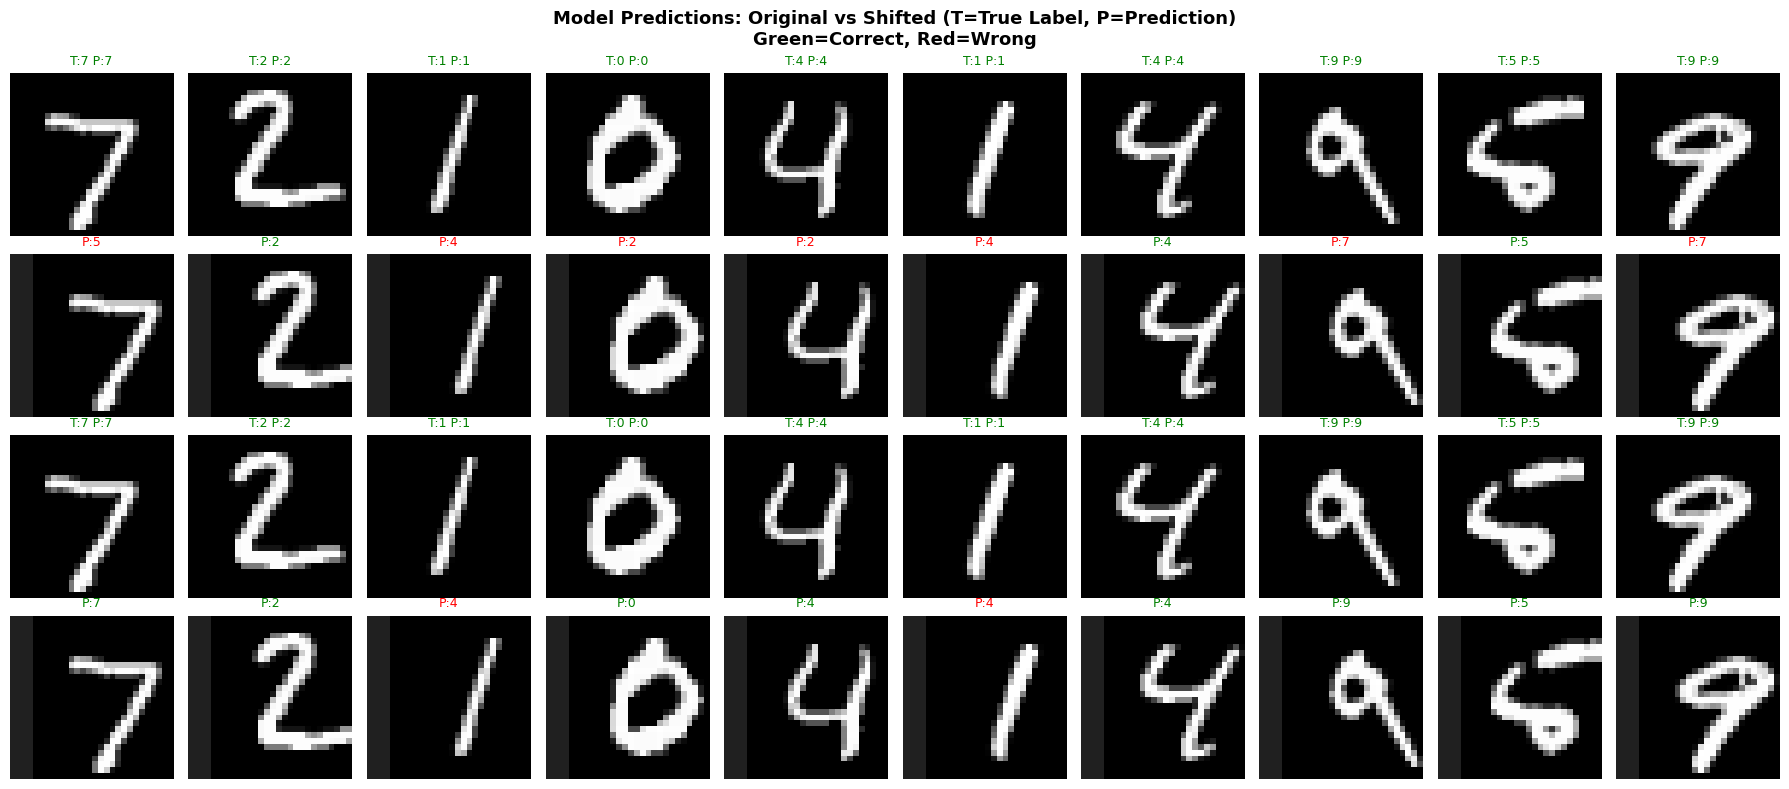

In [17]:
test_samples = 10
sample_original = all_test_images[:test_samples].to(device)
sample_shifted = shifted_test_images[:test_samples].to(device)
sample_labels_batch = all_test_labels[:test_samples]
 
fcnn_model.eval()
cnn_model.eval()

with torch.no_grad():
    fcnn_pred_orig = torch.argmax(fcnn_model(sample_original), dim=1).cpu()
    fcnn_pred_shift = torch.argmax(fcnn_model(sample_shifted), dim=1).cpu()
    cnn_pred_orig = torch.argmax(cnn_model(sample_original), dim=1).cpu()
    cnn_pred_shift = torch.argmax(cnn_model(sample_shifted), dim=1).cpu()
 
fig, axes = plt.subplots(4, test_samples, figsize=(18, 8))

for i in range(test_samples): 
    axes[0, i].imshow(sample_original[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if fcnn_pred_orig[i] == sample_labels_batch[i]:
        axes[0, i].set_title(f'T:{sample_labels_batch[i]} P:{fcnn_pred_orig[i]}', color='green', fontsize=9)
    else:
        axes[0, i].set_title(f'T:{sample_labels_batch[i]} P:{fcnn_pred_orig[i]}', color='red', fontsize=9)
     
    axes[1, i].imshow(sample_shifted[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if fcnn_pred_shift[i] == sample_labels_batch[i]:
        axes[1, i].set_title(f'P:{fcnn_pred_shift[i]}', color='green', fontsize=9)
    else:
        axes[1, i].set_title(f'P:{fcnn_pred_shift[i]}', color='red', fontsize=9)
     
    axes[2, i].imshow(sample_original[i].cpu().squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if cnn_pred_orig[i] == sample_labels_batch[i]:
        axes[2, i].set_title(f'T:{sample_labels_batch[i]} P:{cnn_pred_orig[i]}', color='green', fontsize=9)
    else:
        axes[2, i].set_title(f'T:{sample_labels_batch[i]} P:{cnn_pred_orig[i]}', color='red', fontsize=9)
     
    axes[3, i].imshow(sample_shifted[i].cpu().squeeze(), cmap='gray')
    axes[3, i].axis('off')
    if cnn_pred_shift[i] == sample_labels_batch[i]:
        axes[3, i].set_title(f'P:{cnn_pred_shift[i]}', color='green', fontsize=9)
    else:
        axes[3, i].set_title(f'P:{cnn_pred_shift[i]}', color='red', fontsize=9)

# Add row labels
axes[0, 0].set_ylabel('FCNN\nOriginal', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('FCNN\nShifted', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('CNN\nOriginal', fontsize=11, fontweight='bold')
axes[3, 0].set_ylabel('CNN\nShifted', fontsize=11, fontweight='bold')

plt.suptitle('Model Predictions: Original vs Shifted (T=True Label, P=Prediction)\nGreen=Correct, Red=Wrong', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()